## Visualization in `matplotlib` and `seaborn`

In [ ]:
# Makes it so any variable or statement on it's own line gets printed w/o print()
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [ ]:
# Start with importing the packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
from scipy import stats


# We're also going to tell Jupyter to use inline plotting instead of notebook plotting
# It basically means you don't have to use plt.show() in every cell
%matplotlib inline


## Visualizing differential gene expression results with a volcano plot

A volcano plot is a commonly used visualization to report differentially expressed genes. It is a scatter plot with log fold changes plotted on the x-axis and -log10(p_adj) on the y axis. This allows us to quickly visualize the number and magnitude of differential expression, with the most changed genes at the peak of the 'eruption'

In [ ]:
deg_results = pd.read_csv('~/LECTURE_MATERIALS/DataFiles/deseq_results_melanoma.csv',index_col=0)
display(deg_results)

In [ ]:
# Recalculating significant results
sig_results = deg_results.loc[(deg_results['padj'] < 0.05) & (abs(deg_results['log2FoldChange']) > 1),:]
display(sig_results)

# Calculating top 10 results
top10_results = sig_results.sort_values('padj').head(10)
display(top10_results)


A basic scatter plot can be generated using the `pyplot` function `plt.scatter()`.

In [ ]:
plt.scatter(deg_results['log2FoldChange'],
            -np.log10(deg_results['padj']),
            color="grey");

Multiple plots can be generated in the same figure using `plt.subplots()`. To pick which plot to graph the data, specify the coordinate with the `ax` variable.

To pick which plot to graph the data, specify the coordinate with the `ax` variable.

In [ ]:
fig, ax = plt.subplots(1,2)
ax[0].scatter(deg_results['log2FoldChange'],
            -np.log10(deg_results['padj']),
            color="grey");

Note that you can overlay multiple graphs on the same axis. The order that you plot matters when overlapping.

In [ ]:
fig, ax = plt.subplots(1,2)
ax[0].scatter(deg_results['log2FoldChange'],
            -np.log10(deg_results['padj']),
            color="grey");
ax[0].scatter(sig_results['log2FoldChange'],
            -np.log10(sig_results['padj']),
            color="orange");

In [ ]:
fig, ax = plt.subplots(1,2)
ax[0].scatter(deg_results['log2FoldChange'],
            -np.log10(deg_results['padj']),
            color="grey");
ax[1].scatter(sig_results['log2FoldChange'],
            -np.log10(sig_results['padj']),
            color="orange");

You can also add text to the plot in addition to data points using `plt.text()`. Note that the syntax is: where you want to place the text, followed by what text you want to show.

You can also add plot customizations like x/y labels, titles, legends, etc.

In [ ]:
#plotting 3 layers of colors

plt.scatter(deg_results['log2FoldChange'],
            -np.log10(deg_results['padj']),
            color="grey");
plt.scatter(sig_results['log2FoldChange'],
            -np.log10(sig_results['padj']),
            color="orange");

plt.scatter(top10_results['log2FoldChange'],
            -np.log10(top10_results['padj']),
            color='red');

for index, row in top10_results.iterrows(): #iterrows is like the data frame version of enumerate
  plt.text(row['log2FoldChange'],-np.log10(row['padj']),index);

plt.xlabel("Log2 Fold Change");
plt.ylabel("-log10 p-adj");
plt.legend(['All','DEGs','Top10']);
plt.title("Metastatic vs primary melanocytes");

### Comparing groups of data with a swarm plots / box plots


We'll start by loading toy data I generated to mirror some of the plots that are observed in the paper.

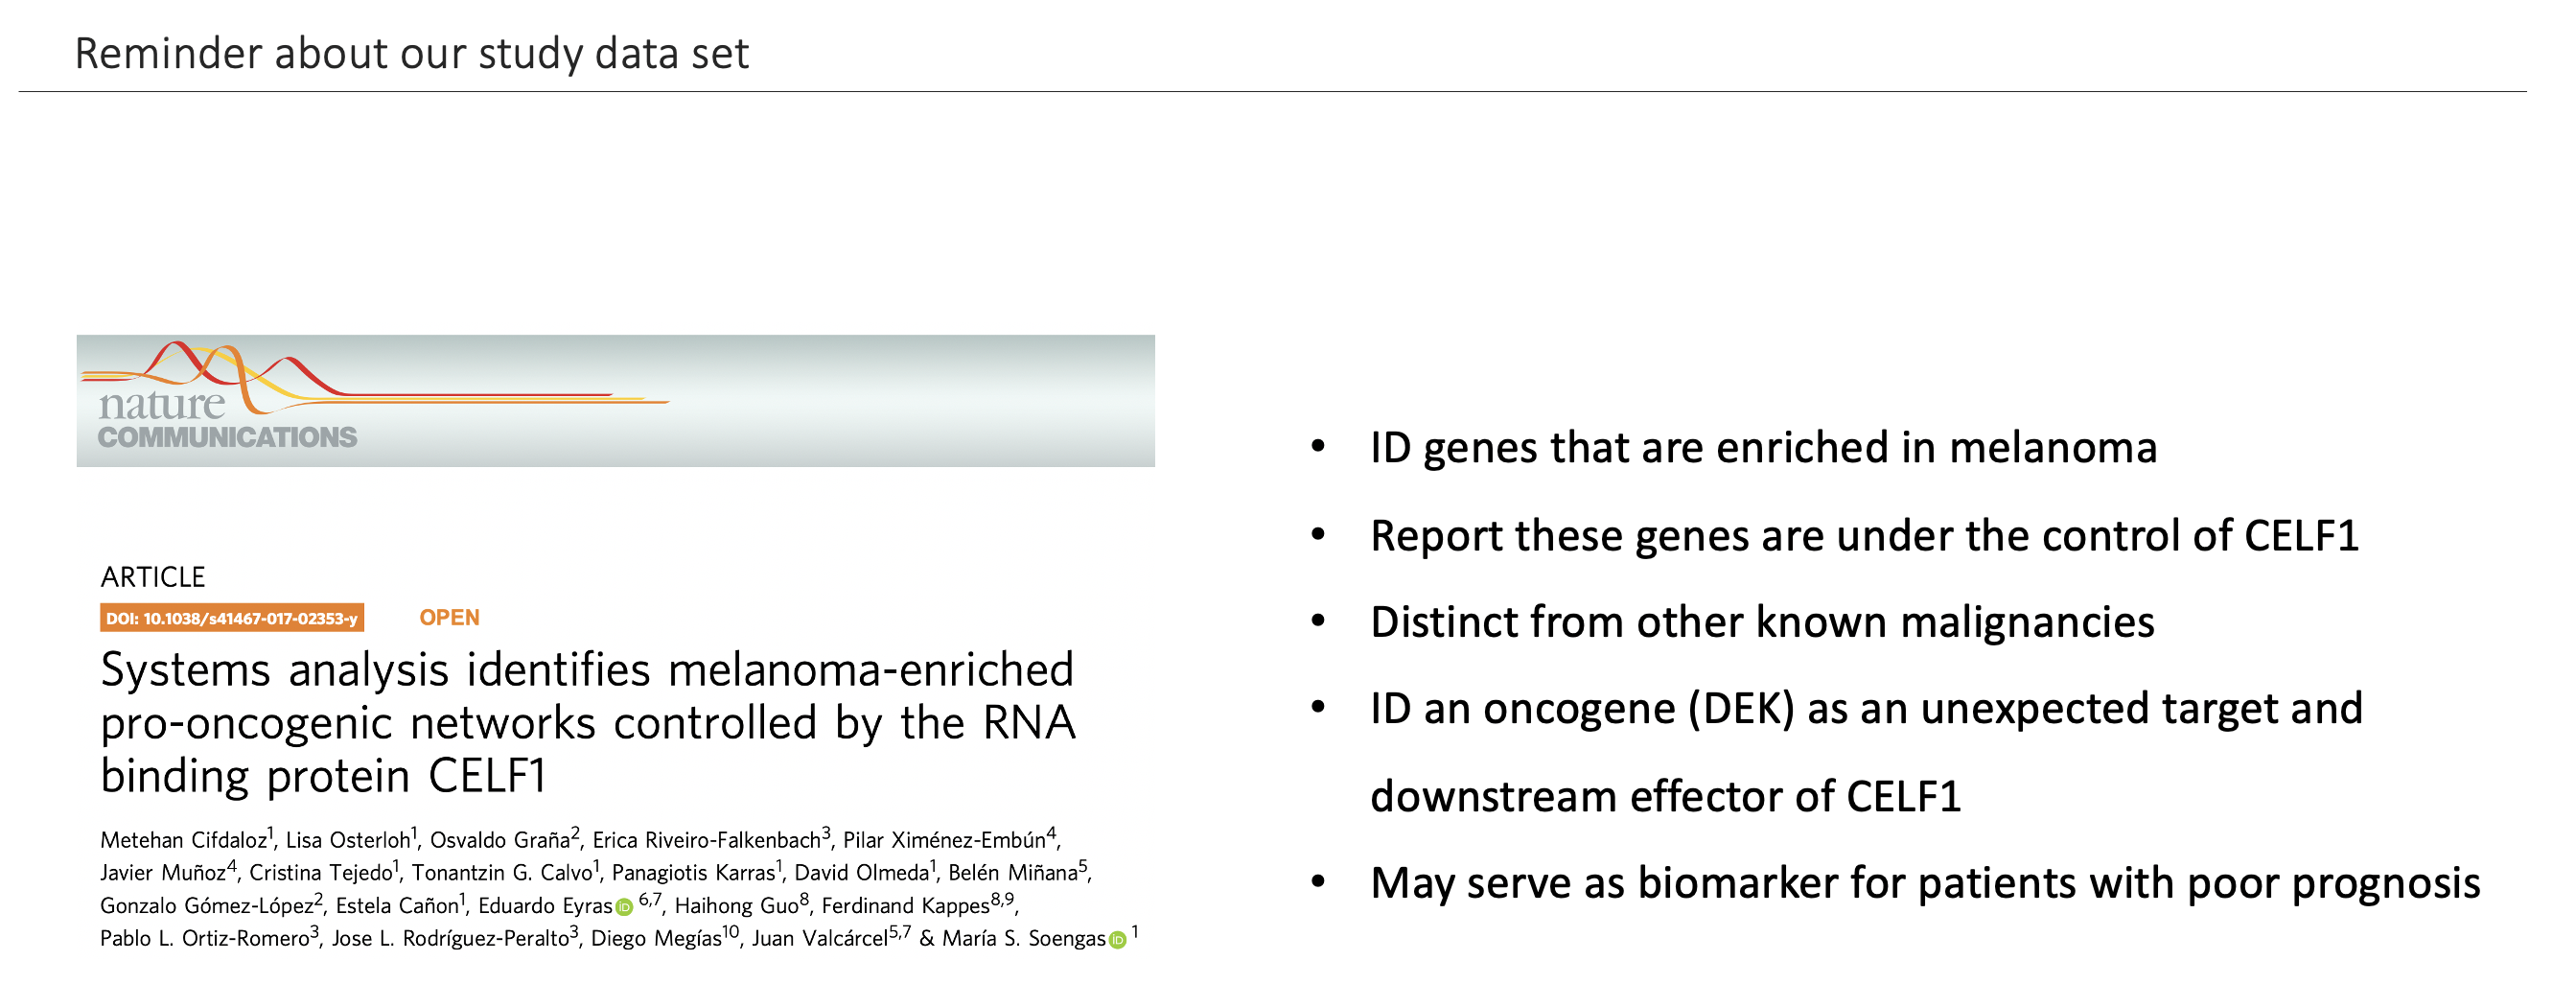




Let's begin with Fig. 1C: CELF1 mRNA expression levels in The Cancer Genome Atlas (TCGA) melanoma samples, categorized by disease stage.




In the paper there are plots that we can recapitulate with toy data generated and placed on canvas *(Courtesy Andrew Gustin)*.  

You can see a figure of interest here:

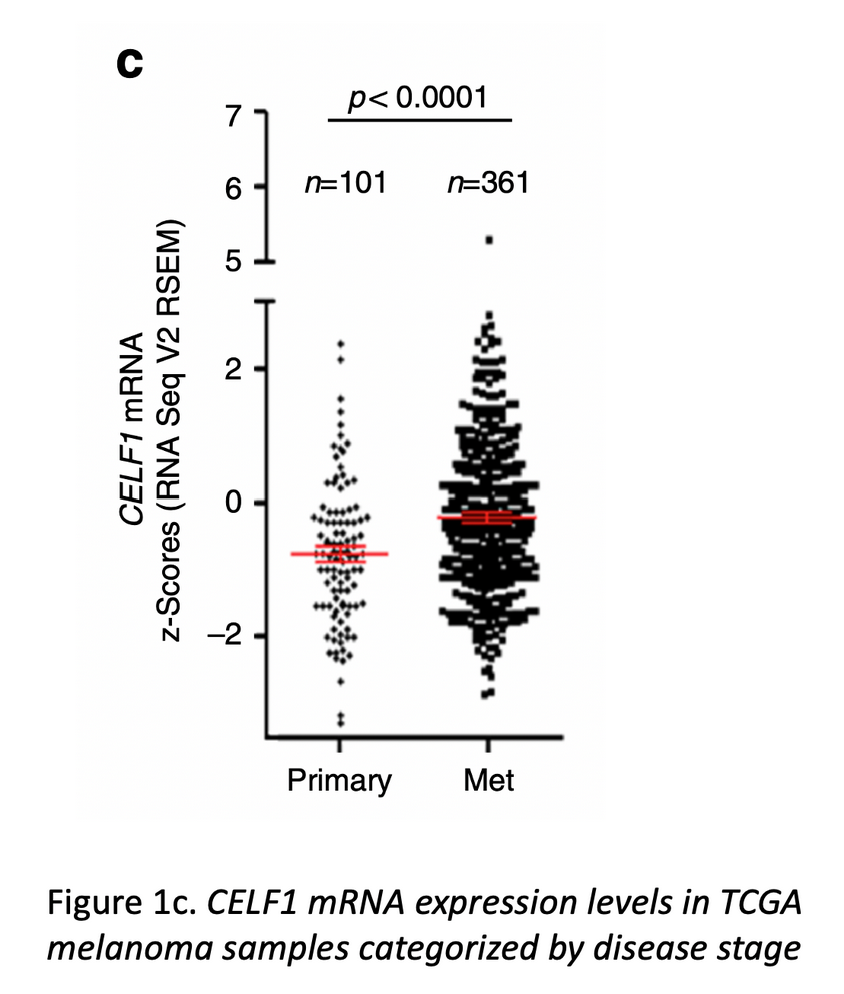

To start, we can load the toy data for figure 1C

In [ ]:
# Import toy data as comma-seperated text file
meta_1c = pd.read_csv("~/LECTURE_MATERIALS/DataFiles/figure_01c.csv")
print(meta_1c.shape)
meta_1c.head(10)

Utilize the "wrapper" called Seaborn to generate visually clear/
interesting plots

In [ ]:
# We are using the Seaborn alias "sns" to call the seaborn package
sns.catplot(x="disease_stage", y="CELF1_mRNA_z-scores", data=meta_1c);



The `kind = "swarm"` argument eliminates all data overlap to clearly reveal the shape of the distribution with the column itself, and the `hue = "disease_stage"` argument gives you the option to color the data points by a column in  your input data frame

In [ ]:
sns.catplot(x="disease_stage", y="CELF1_mRNA_z-scores", data=meta_1c,kind = "swarm", hue="disease_stage");
plt.xlabel("Disease Stage");
plt.ylabel("CELF1 mRNA z-Scores");
plt.legend(['primary','met']); # adds a legend

### <font color=brown>Hands on practice</font>

Let's encode an additional layer of information in the Figure 1C mimic plot above


In [ ]:
import random
rand_list=[]
n=300
for i in range (n):
    rand_list.append(random.randint(3,9))
print(rand_list)

1. Add an extra metadata category to the meta_1C data frame and fill it with toy data

2. Plot your new figure 1C with the additional data

In [ ]:
#1

In [ ]:
#2

#### Boxplots

The boxplot wasn't invented until 1970; John Tukey developed it as a visual tool to quickly interpret several aspects of a large data set.



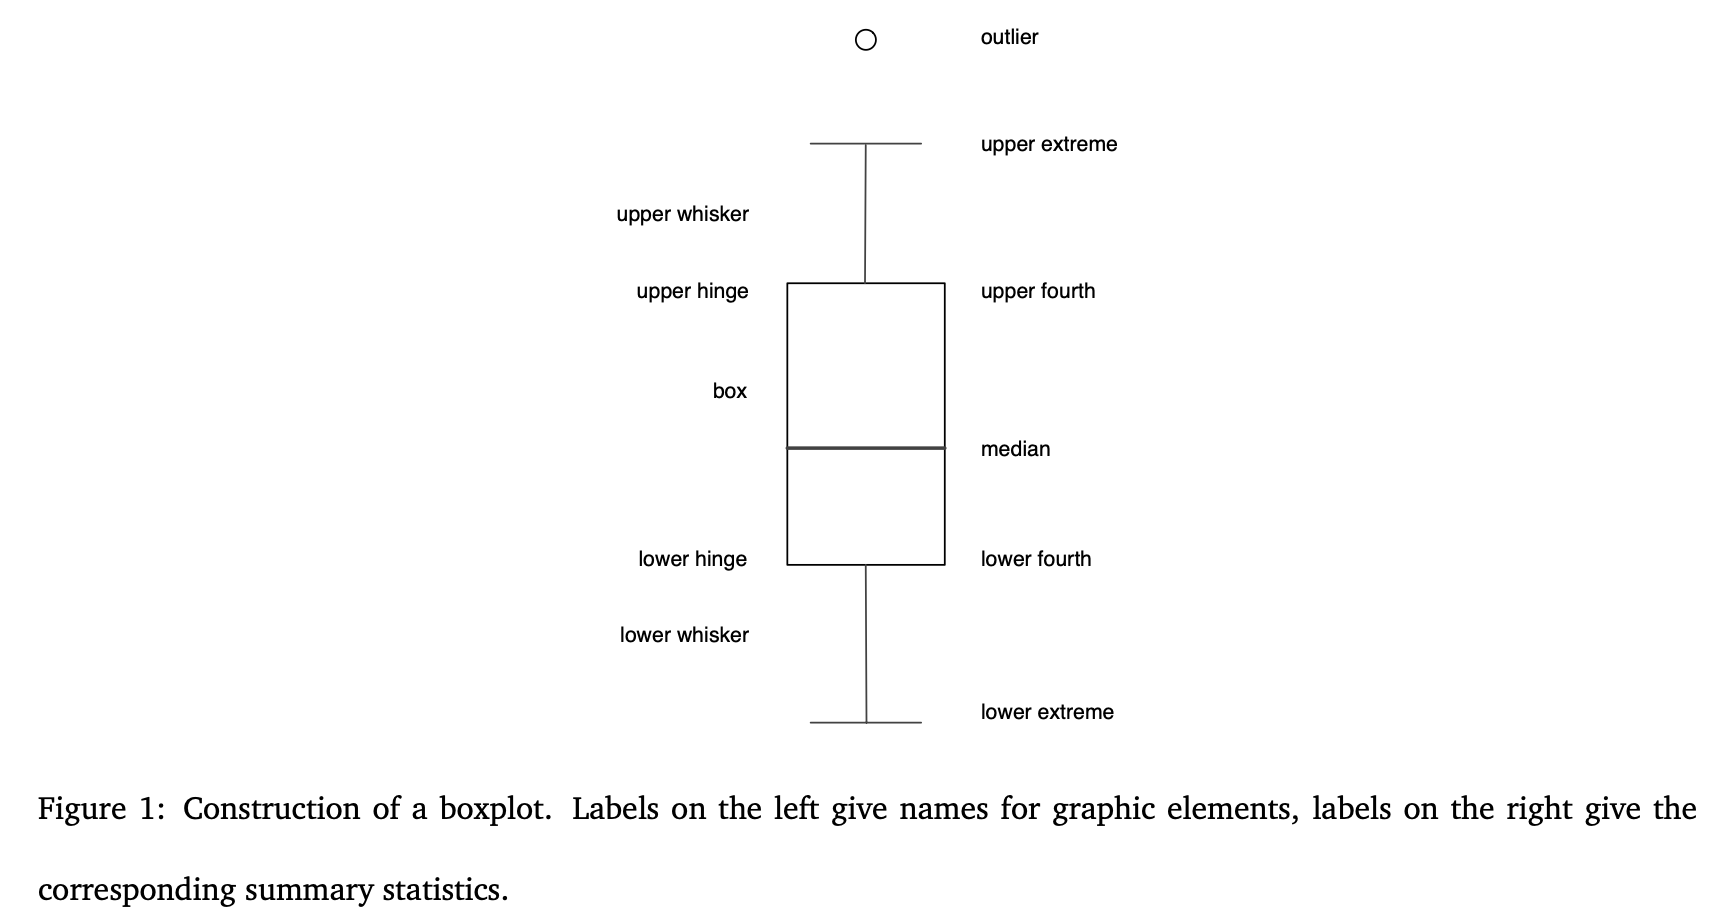


 Check out more about the origins and evolution of the boxplot here: https://vita.had.co.nz/papers/boxplots.pdf (bonus - the paper is written in part by Hadley Wickham who developed ggplot2 for R)

Seaborn makes generating boxplots easy with a sns.boxplot command

In [ ]:
sns.boxplot(x="disease_stage", y="CELF1_mRNA_z-scores", data=meta_1c, hue="disease_stage")
plt.xlabel("Disease Stage")
plt.ylabel("CELF1 mRNA z-Scores");

A boxplot isn't a perfect tool, and it can hide things like bi-modal distributions.  Adding the individual data points as an overlay can address this.

In [ ]:
sns.boxplot(x="disease_stage", y="CELF1_mRNA_z-scores", data=meta_1c, hue="disease_stage")
sns.catplot(x="disease_stage", y="CELF1_mRNA_z-scores", data=meta_1c,kind = "swarm", hue="disease_stage")
plt.xlabel("Disease Stage")
plt.ylabel("CELF1 mRNA z-Scores");

Notice that we get two graphs.  

We can address this by a) calling catplot first or b)using sns.swarmplot, which doesn't "overrule" the sns.boxplot

In [ ]:
sns.catplot(x="disease_stage", y="CELF1_mRNA_z-scores", data=meta_1c, kind = "swarm", hue="disease_stage")
sns.boxplot(x="disease_stage", y="CELF1_mRNA_z-scores", data=meta_1c, hue="disease_stage")
#sns.swarmplot(x="disease_stage", y="CELF1_mRNA_z-scores", data=meta_1c, hue="disease_stage")
plt.xlabel("Disease Stage")
plt.ylabel("CELF1 mRNA z-Scores");

the default color setting makes the points somewhat difficult to see; let's change that.

In [ ]:
sns.boxplot(x="disease_stage", y="CELF1_mRNA_z-scores", data=meta_1c, hue="disease_stage")
sns.swarmplot(x="disease_stage", y="CELF1_mRNA_z-scores", data=meta_1c, color = 'k')
plt.xlabel("Disease Stage")
plt.ylabel("CELF1 mRNA z-Scores");

Great - those points are clearly visible now.  They also may be a bit distracting - how can we bring the two elements into a bit more harmony?  


### <font color = brown > Practice Questions:

1. What other colors could we use for the data points?  Use google or ?sns.swarmplot to find out.   

*Note:* as you search for potential strategies, try to keep in mind some of the data viz do's and don'ts discussed in the lecture.

2. Let's say we'd like to change the appearance of the boxplot itself - use the same search techniques to find out how to change the thickness of the boxplot lines and the width of the boxes themselves.  

In [ ]:
#1

In [ ]:
#2

#### <font color = blue > Optional bonus: line plots with error bars (like Figure 2b)

Impaired growth of SK-Mel-103 and UACC-62 cells upon CELF1 depletion. Time points represent days after lentiviral infection.

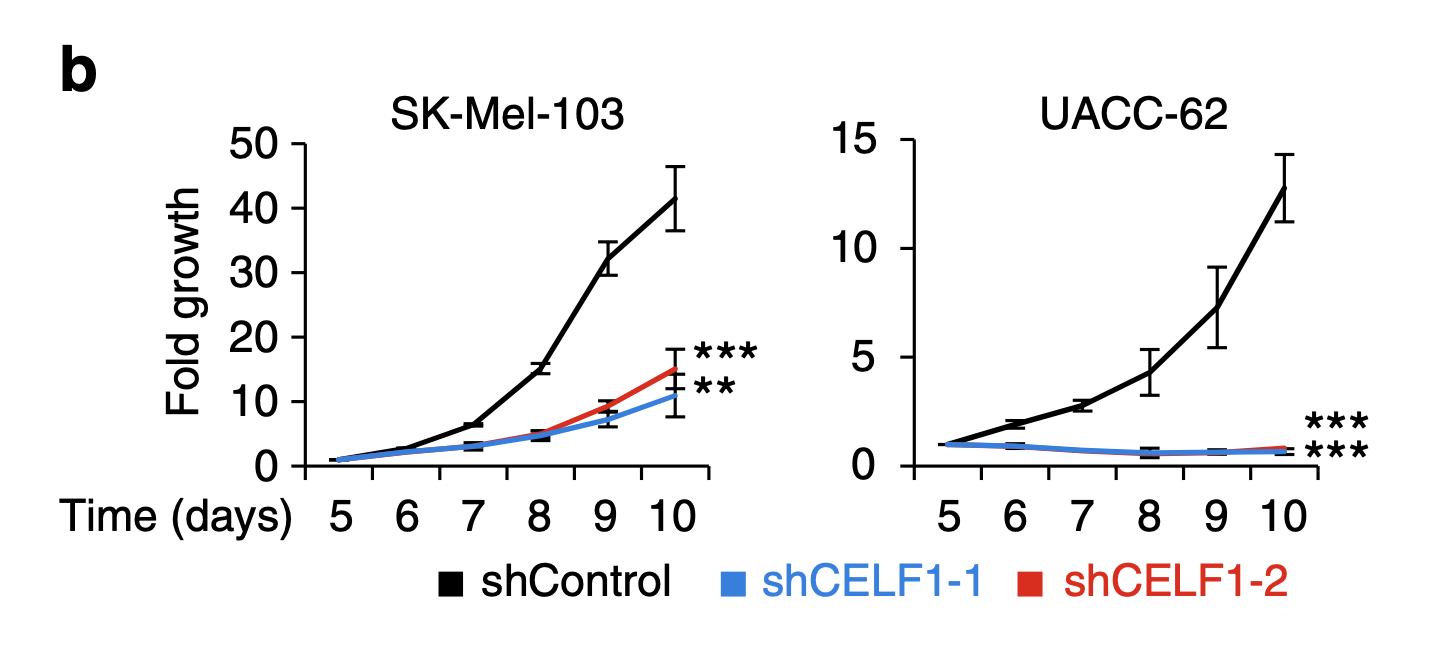

In [ ]:
# Import comma-seperated data from a text file
meta_2b = pd.read_csv("~/LECTURE_MATERIALS/DataFiles/figure_02b.csv")
meta_2b.head(5)

In [ ]:
meta_2b.CELF_depletion.unique()

Figure 2b actually contains 2 graphics. Facets are a common term used in several visualization packages to create any number of plots that share a common x-y axis but differ in the population being displayed.

Here, we will initialize a facted plot by calling sns.FacetGrid and then plot the data within those facets.

In [ ]:
g = sns.FacetGrid(meta_2b, col="cell_line", hue="CELF_depletion");
g.map(sns.pointplot, "experimental_day","fold_growth",errorbar = ('sd'));
g.add_legend();

# Plotnine

https://plotnine.org/

`Plotnine` is a plotting package for python that has identical syntax as `ggplot` in R. If you are used to `ggplot` and/or enjoy its plotting capabilities, then this might be a good package for you.

In [ ]:
import plotnine as p9

In [ ]:
# Gallery, distributions
(
    p9.ggplot(meta_1c,aes(x="disease_stage", y="CELF1_mRNA_z-scores"))
    + p9.geom_boxplot(aes(fill="disease_stage"))
    + p9.geom_jitter()
    + p9.xlab("Stage")
    + p9.ylab("CELF1 mRNA z-Scores")
)

## Altair

***https://www.youtube.com/watch?v=ms29ZPUKxbU***

Altair tutorial given by Jake VanderPlas, designer of Altair wrapper for Vega-Lite

In [ ]:
import altair as alt

In [ ]:
cars = pd.read_csv('~/LECTURE_MATERIALS/DataFiles/cars.csv',index_col=0)

In [ ]:
cars.head(10)

In [ ]:
#create a chart with data set cars
#convey data values with points
alt.Chart(cars).mark_point()

In [ ]:
#encoding is a way to map visual elements of the chart - stuff that requires ink - to columns in the data set.
# you can reference the columns you want to encode by name
alt.Chart(cars).mark_point().encode(
    x = "MPG_City",
    y = "Horsepower",
    color = "Origin"

)

You can tell Altair to mark specific intervals of interest

In [ ]:
brush = alt.selection_interval(encodings = ['x','y'])
alt.Chart(cars).mark_point().encode(
    x = "MPG_City",
    y = "Horsepower",
    color = alt.when(brush).then("Origin").otherwise(alt.ColorValue("gray"))

).add_params(
    brush
)

Altair enables you to use the interval selection to inform the visual properties of a second plot

In [ ]:
brush = alt.selection_interval(encodings = ['x','y'])
base = alt.Chart(cars).mark_point().encode(
    y='Horsepower',
    color=alt.when(brush).then("Origin").otherwise(alt.ColorValue("gray")),
).add_params(
    brush
).properties(
    width=250,
    height=250
)

base.encode(x='MPG_City') | base.encode(x='Weight')

*Note*: A nice application of this for biological data might be to visualize subsets of cells from flow cytometry data (interactive gating)

A second pair of interactive plots that might be useful:

In [ ]:
brush = alt.selection_interval(encodings = ['x','y'])

points = alt.Chart(cars).mark_point().encode(
    x='Horsepower',
    y='MPG_City',
    color=alt.when(brush).then("Origin").otherwise(alt.value("lightgray"))
).add_params(
    brush
)

bars = alt.Chart(cars).mark_bar().encode(
    y='Origin',
    color='Origin',
    x='count(Origin)'
).transform_filter(
    brush
)

points & bars
